In [ ]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt

DATASET_PATH = Path("../data/interview_forge_v3_complete.csv")

def load_dataset(dataset_path: Path):

    if not dataset_path.exists():
        raise ValueError(f"The provided path : {dataset_path} doesn't exists")

    return pd.read_csv(dataset_path)

df_interviews = load_dataset(DATASET_PATH)

df_interviews.head()

,question,keywords,role,sector,interview_stage,interviewer,question_category,question_level,candidate_quality,candidate_answer,feedback,follow_up_question,generation_status,generation_error
0,You've been tasked with implementing a new net...,"['IoT device farm', 'minimal latency', 'HACCP ...",Network Engineer,FoodTech,Stage 1: HR Screening,"HR Recruiter - a sharp, experienced talent acq...",Communication & Soft Skills,Level 3: Edge Case & Conflict,weak,I would start by assessing the impact of the d...,The candidate acknowledges the need to priorit...,Can you explain how you would ensure that the ...,success,NaN
1,Suppose we're planning to develop a new AI-pow...,"['AI', 'anomaly detection', 'TensorFlow', 'PyT...",Engineering Manager,Drones & Aerial Platforms,Stage 4: Product & System Vision,Product Manager / VP of Engineering / CTO - a ...,Innovation & Emerging Tech,Level 1: Foundational,strong,I think PyTorch would be a better choice for t...,The candidate provides a clear rationale for c...,Could you explain how the event-driven archite...,success,NaN
2,You've been tasked to perform a penetration te...,"['Django', 'AngularJS', 'CSRF Protection', 'Pe...",Penetration Tester / Ethical Hacker,Cybersecurity,Stage 2: Technical Assessment & Deep Dive,Senior Engineer / Tech Lead / Peer Developer -...,Tools & Frameworks,Level 1: Foundational,weak,"Well, CSRF protection is important for web app...",The candidate identified the importance of CSR...,Can you explain how a CSRF attack would work i...,success,NaN
3,Scenario: The DevOps team has been experiencin...,"['Selenium Grid', 'HIPAA compliance', 'intermi...",Scrum Master / Agile Coach,Cybersecurity,Stage 2: Technical Assessment & Deep Dive,Senior Engineer / Tech Lead / Peer Developer -...,Debugging & Troubleshooting,Level 1: Foundational,strong,I would start by checking the Selenium Grid lo...,The candidate provides a clear and structured ...,How would you prioritize the fixes if you iden...,success,NaN
4,In our current project to develop an autonomou...,"['autonomous drone fleet', 'real-time data pro...",Solutions Architect,Drones & Aerial Platforms,Stage 4: Product & System Vision,Product Manager / VP of Engineering / CTO - a ...,Technical Roadmap & Strategy,Level 3: Edge Case & Conflict,average,I would start by evaluating the current system...,The candidate acknowledges the problem and pre...,Can you elaborate on how you would assess the ...,success,NaN


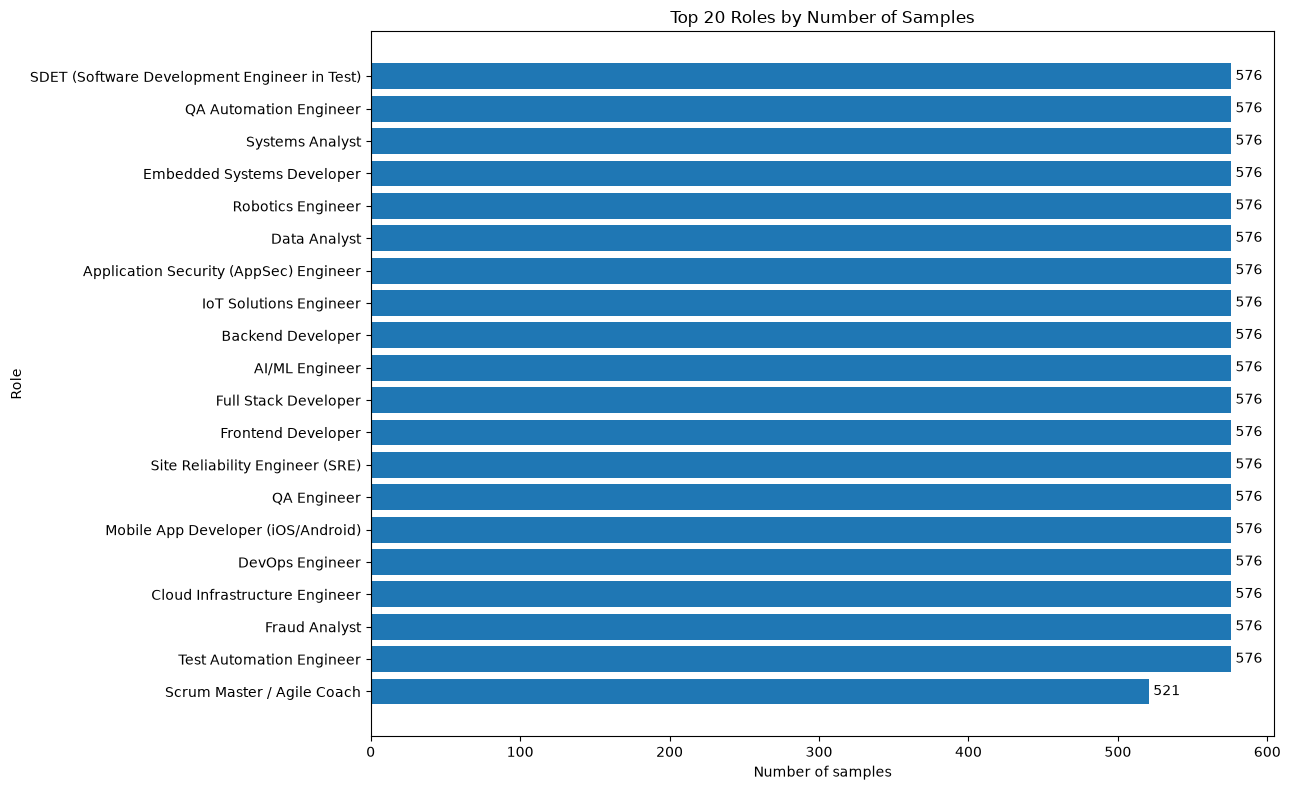

In [12]:
top_n = 20

roles = df_interviews["role"].value_counts().head(top_n).sort_values()

plt.figure(figsize=(13, 8))
bars = plt.barh(roles.index, roles.values)

plt.xlabel("Number of samples")
plt.ylabel("Role")
plt.title(f"Top {top_n} Roles by Number of Samples")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [13]:
roles = df_interviews["role"].value_counts()

print(f"Total number of unique roles: {len(roles)}")
print(f"Total number of samples: {len(df_interviews)}")
print(f"Mean samples/role: {roles.mean():.2f}")
print(f"Median samples/role: {roles.median():.2f}")
print(f"Min samples/role: {roles.min()}")
print(f"Max samples/role: {roles.max()}")

Total number of unique roles: 38
Total number of samples: 20444
Mean samples/role: 538.00
Median samples/role: 548.50
Min samples/role: 479
Max samples/role: 576


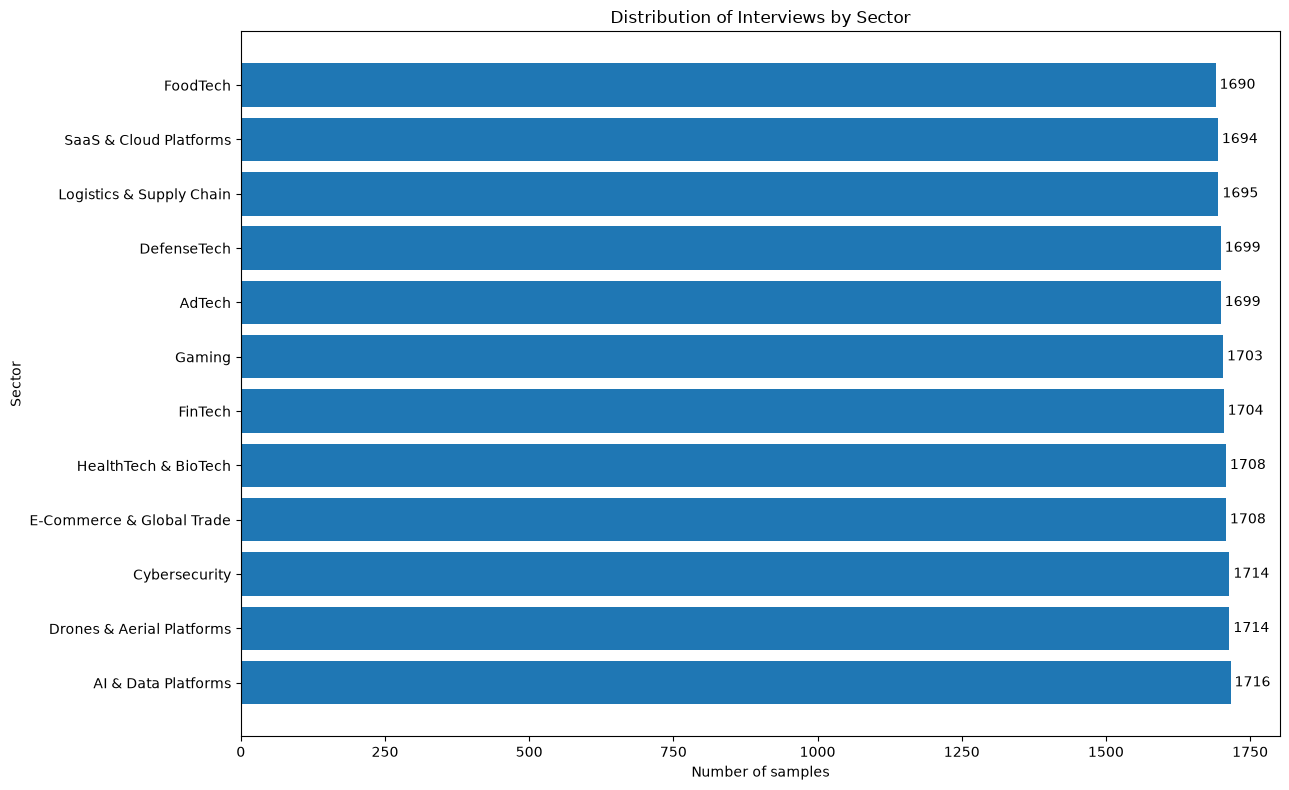

In [15]:
sectors = df_interviews["sector"].value_counts()


plt.figure(figsize=(13, 8))
bars = plt.barh(sectors.index, sectors.values)

plt.xlabel("Number of samples")
plt.ylabel("Sector")
plt.title("Distribution of Interviews by Sector")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

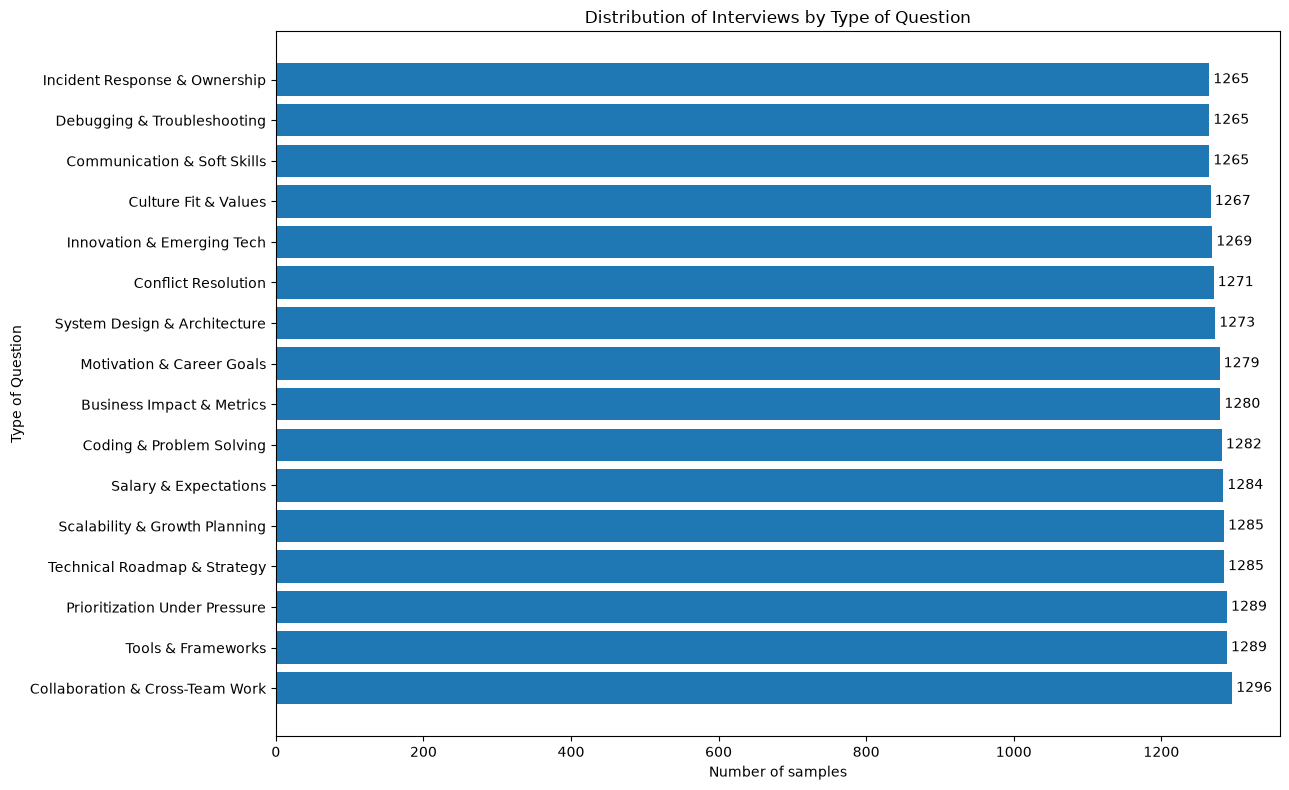

In [17]:
questions = df_interviews["question_category"].value_counts()

plt.figure(figsize=(13, 8))
bars = plt.barh(questions.index, questions.values)

plt.xlabel("Number of samples")
plt.ylabel("Type of Question")
plt.title("Distribution of Interviews by Type of Question")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

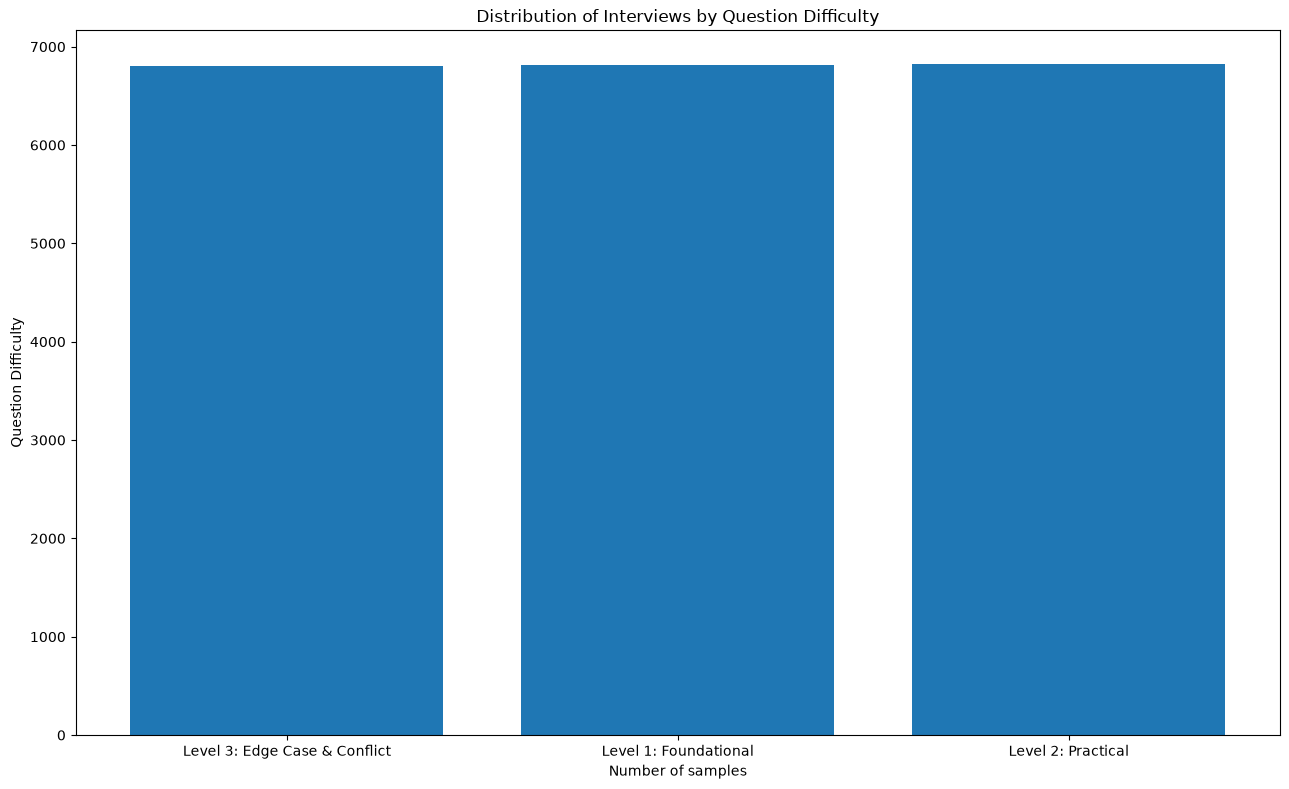

In [20]:
questions_difficulties = df_interviews["question_level"].value_counts().sort_values()

plt.figure(figsize=(13, 8))
bars = plt.bar(questions_difficulties.index, questions_difficulties.values)

plt.xlabel("Number of samples")
plt.ylabel("Question Difficulty")
plt.title("Distribution of Interviews by Question Difficulty")


plt.tight_layout()
plt.show()

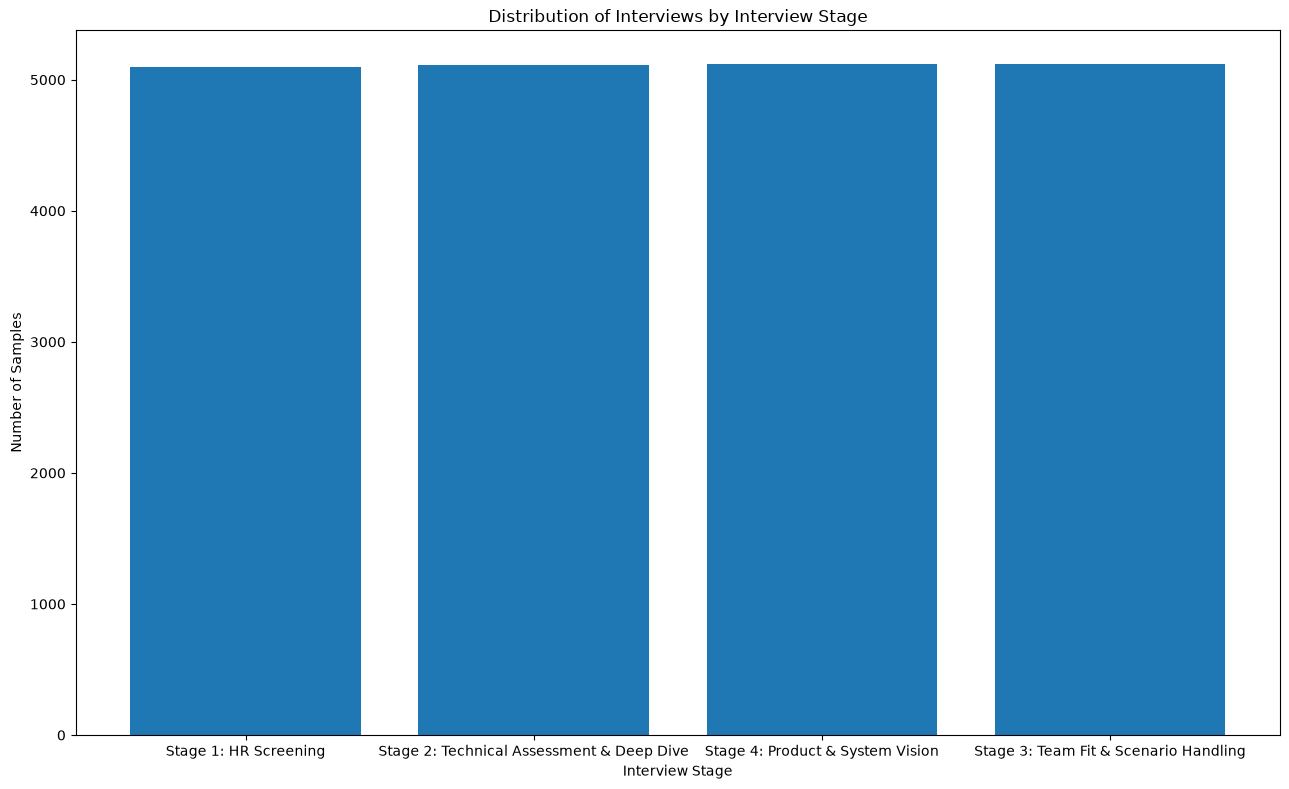

In [22]:
interview_stages = df_interviews["interview_stage"].value_counts().sort_values()

plt.figure(figsize=(13, 8))
bars = plt.bar(interview_stages.index, interview_stages.values)

plt.xlabel("Interview Stage")
plt.ylabel("Number of Samples")
plt.title("Distribution of Interviews by Interview Stage")


plt.tight_layout()
plt.show()

HR             5095
Senior         5109
Product        5119
Engineering    5121
Name: count, dtype: int64


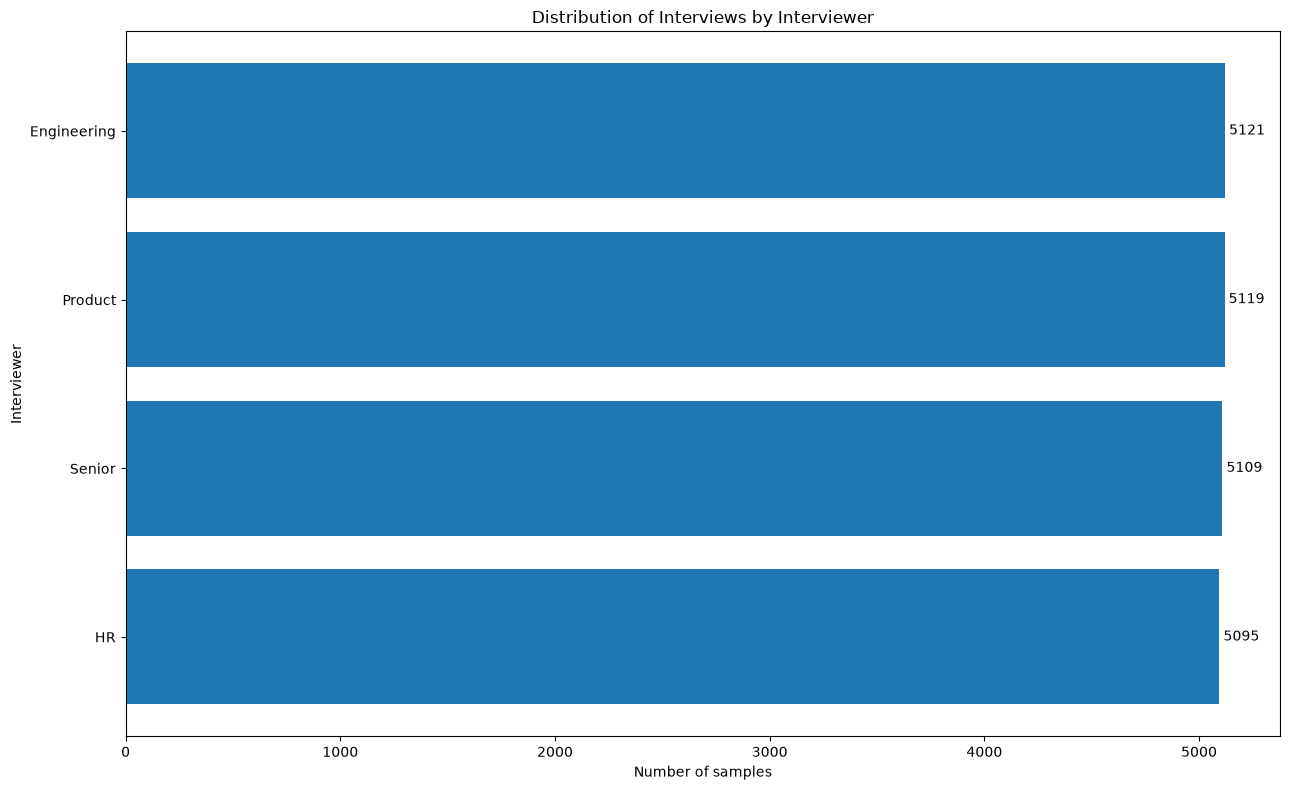

In [ ]:
interviewers = df_interviews["interviewer"].value_counts().sort_values()

labels = interviewers.index.to_list()

labels = [label.split(" ")[0] for label in labels]


interviewers.index = labels

interviewers = interviewers.groupby(interviewers.index).sum().sort_values()


plt.figure(figsize=(13, 8))
bars = plt.barh(interviewers.index, interviewers.values)

plt.xlabel("Number of samples")
plt.ylabel("Interviewer")
plt.title("Distribution of Interviews by Interviewer")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [57]:
pd.crosstab(
    df_interviews["question_level"],
    df_interviews["question_category"],
    normalize="columns"
)

question_category,Business Impact & Metrics,Coding & Problem Solving,Collaboration & Cross-Team Work,Communication & Soft Skills,Conflict Resolution,Culture Fit & Values,Debugging & Troubleshooting,Incident Response & Ownership,Innovation & Emerging Tech,Motivation & Career Goals,Prioritization Under Pressure,Salary & Expectations,Scalability & Growth Planning,System Design & Architecture,Technical Roadmap & Strategy,Tools & Frameworks
question_level,,,,,,,,,,,,,,,,
Level 1: Foundational,0.328906,0.335413,0.330247,0.333597,0.329662,0.333860,0.339921,0.327273,0.330969,0.334636,0.335144,0.330997,0.335409,0.334643,0.335409,0.334368
Level 2: Practical,0.335938,0.335413,0.338735,0.339921,0.335169,0.332281,0.323320,0.334387,0.338849,0.331509,0.333592,0.334891,0.331518,0.329144,0.333074,0.333592
Level 3: Edge Case & Conflict,0.335156,0.329173,0.331019,0.326482,0.335169,0.333860,0.336759,0.338340,0.330181,0.333855,0.331265,0.334112,0.333074,0.336214,0.331518,0.332040


In [58]:
pd.crosstab(
    df_interviews["role"],
    df_interviews["question_category"]
)

question_category,Business Impact & Metrics,Coding & Problem Solving,Collaboration & Cross-Team Work,Communication & Soft Skills,Conflict Resolution,Culture Fit & Values,Debugging & Troubleshooting,Incident Response & Ownership,Innovation & Emerging Tech,Motivation & Career Goals,Prioritization Under Pressure,Salary & Expectations,Scalability & Growth Planning,System Design & Architecture,Technical Roadmap & Strategy,Tools & Frameworks
role,,,,,,,,,,,,,,,,
AI/ML Engineer,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36
Application Security (AppSec) Engineer,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36
Backend Developer,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36
Blockchain / Smart Contract Developer,33,32,34,30,34,26,30,31,30,32,35,33,33,31,34,30
Business Intelligence (BI) Analyst,35,30,31,30,31,27,30,30,31,27,33,28,28,30,33,33
Cloud Infrastructure Engineer,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36
Computer Vision Engineer,31,31,32,31,31,30,29,31,33,32,30,30,28,32,34,31
Data Analyst,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36
Data Engineer,32,33,32,29,34,31,32,34,29,33,31,30,32,31,31,34


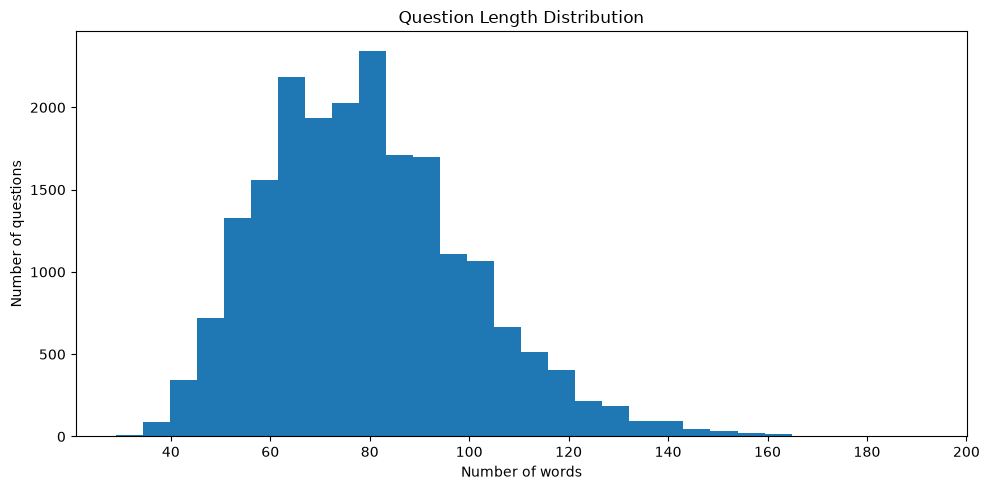

In [63]:
df_interviews["question_words"] = (
    df_interviews["question"]
    .str.split()
    .str.len()
)

df_interviews["question_words"].describe()

plt.figure(figsize=(10, 5))

plt.hist(
    df_interviews["question_words"],
    bins=30
)

plt.xlabel("Number of words")
plt.ylabel("Number of questions")
plt.title("Question Length Distribution")

plt.tight_layout()
plt.show()

In [56]:
print("Exact duplicated questions:")
print(df_interviews["question"].duplicated().sum())

duplicates = df_interviews[
    df_interviews["question"].duplicated(keep=False)
].sort_values("question")

duplicates[
    ["question", "role", "question_category", "question_level"]
].head(30)

Exact duplicated questions:
0


,question,role,question_category,question_level
